## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

In [2]:
df = pd.read_csv("/content/amazon_delivery.csv")
df.shape

(43739, 16)

## 3. Initial Inspection

In [3]:
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [5]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


## 4. Data Cleaning

In [6]:
df.isnull().sum()

,0
Order_ID,0
Agent_Age,0
Agent_Rating,54
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [7]:
categorical_cols = ['Traffic', 'Weather', 'Vehicle', 'Area', 'Category']

for col in categorical_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace(['NaN', 'nan', 'NAN', 'None', 'none', ''], np.nan)
    )


In [8]:
df.isnull().sum()

,0
Order_ID,0
Agent_Age,0
Agent_Rating,54
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [9]:
df.duplicated().sum()

np.int64(0)

##Filling Missing Values

In [10]:

df['Weather'].fillna(df['Weather'].mode()[0], inplace=True) # since it is categorical mode is used.
df['Traffic'].fillna(df['Traffic'].mode()[0], inplace=True) # since it is categorical mode is used.
df['Agent_Rating'].fillna(df['Agent_Rating'].mean(), inplace=True)  # since it is numerical mean is used


/tmp/ipython-input-567067080.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weather'].fillna(df['Weather'].mode()[0], inplace=True) # since it is categorical mode is used.
/tmp/ipython-input-567067080.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

## 5. Feature Engineering

* Setting Up Delivery Date and Time and Delay

In [11]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%Y-%m-%d', errors='coerce')


In [12]:
df['Pickup_Time'] = pd.to_datetime(
    df['Order_Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Pickup_Time'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)


In [13]:
df['order_hour'] = df['Pickup_Time'].dt.hour
df['order_day'] = df['Order_Date'].dt.dayofweek
df['is_weekend'] = df['order_day'].isin([5,6]).astype(int)



* setting up distance

In [14]:
!pip install haversine
from haversine import haversine

df['delivery_distance_km'] = df.apply(
    lambda x: haversine(
        (x['Store_Latitude'], x['Store_Longitude']),
        (x['Drop_Latitude'], x['Drop_Longitude'])
    ),
    axis=1
)


In [15]:
df['delivery_distance_km'].describe()


,delivery_distance_km
count,43739.000000
mean,38.561806
std,534.565038
min,1.465069
25%,4.663439
50%,9.220463
75%,13.682398
max,19692.701807


there definitely exist outliers in distace

In [16]:
Q1 = df['delivery_distance_km'].quantile(0.25)
Q3 = df['delivery_distance_km'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['delivery_distance_km'] >= lower) &
              (df['delivery_distance_km'] <= upper)]


## 6. Encoding

* time factors

In [17]:
def time_bucket(h):
    if 6 <= h < 12:
        return 'Morning'
    elif 12 <= h < 16:
        return 'Afternoon'
    elif 16 <= h < 20:
        return 'Evening'
    else:
        return 'Night'

df['time_bucket'] = df['order_hour'].apply(time_bucket)


In [18]:
q1 = df['Delivery_Time'].quantile(0.33)
q2 = df['Delivery_Time'].quantile(0.66)

def categorize(time):
    if time <= q1:
        return "On-Time"
    elif time <= q2:
        return "At-Risk"
    else:
        return "Delayed"

df['Delivery_Status'] = df['Delivery_Time'].apply(categorize)


In [19]:
time_delay = {
    'On-Time': 0,
    'At-Risk': 1,
    'Delayed': 2
}
df['Delivery_Status_Enc'] = df['Delivery_Status'].map(time_delay)
df['is_delayed'] = df['Delivery_Status_Enc'].apply(lambda x: 1 if (x > 1) else 0)


* Environment Factors

1.   Weather
2.   Traffic



In [20]:
df['Weather'].value_counts()



,count
Weather,
Fog,7474
Stormy,7352
Cloudy,7264
Sandstorms,7215
Windy,7198
Sunny,7048


In [21]:
weather_map = {
    'Fog': 5,
    'Stormy': 4,
    'Cloudy': 3,
    'Sandstorms': 2,
    'Windy': 1,
    'Sunny': 0
}
df['weather_severity'] = df['Weather'].map(weather_map)


In [22]:
df['Traffic'].value_counts()


,count
Traffic,
Low,14999
Jam,13678
Medium,10595
High,4279


In [23]:
traffic_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Jam': 3
}
df['traffic_severity'] = df['Traffic'].map(traffic_map)


* Logistics and Categories

In [24]:
df['Category'].value_counts()

,count
Category,
Electronics,2839
Books,2809
Jewelry,2789
Toys,2768
Skincare,2762
Snacks,2759
Outdoors,2738
Apparel,2715
Sports,2706


* Agent Related

In [25]:
df['agent_age_group'] = pd.cut(
    df['Agent_Age'],
    bins=[18, 25, 35, 50, 65],
    labels=['Young', 'Mid', 'Senior', 'Experienced']
)


In [26]:
df['rating_bucket'] = pd.cut(
    df['Agent_Rating'],
    bins=[0, 2.5, 3.5, 5],
    labels=['Low', 'Medium', 'High']
)


## 7. Adding New Features

In [27]:
df['traffic_distance'] = df['traffic_severity'] * df['delivery_distance_km']
df['weather_distance'] = df['weather_severity'] * df['delivery_distance_km']


## 8. Reviewing Graphs

* Delivery Duration Distribution

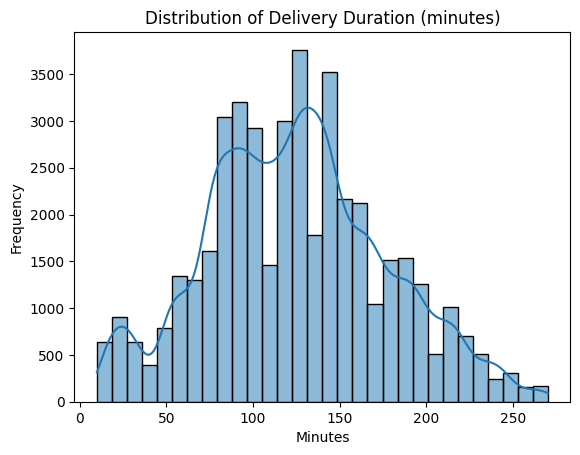

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Delivery_Time'], bins=30, kde=True)
plt.title('Distribution of Delivery Duration (minutes)')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()


* Target distribution

    *   Shows class imbalance
    *   Decides metrics (recall/F1)




<Axes: xlabel='Delivery_Status', ylabel='count'>

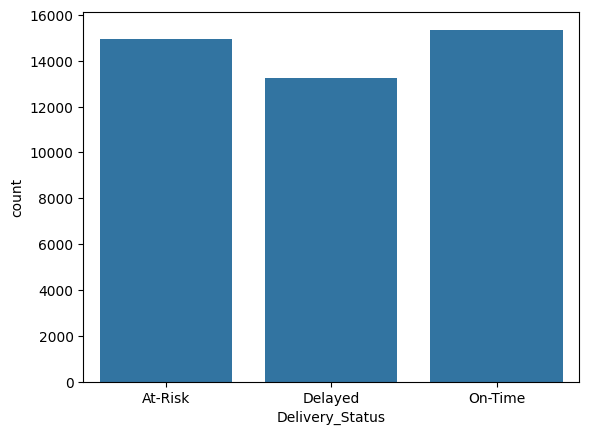

In [29]:
sns.countplot(x='Delivery_Status', data=df)


* Delivery time vs target

    * Shows whether classes are separable



<Axes: xlabel='Delivery_Time', ylabel='Density'>

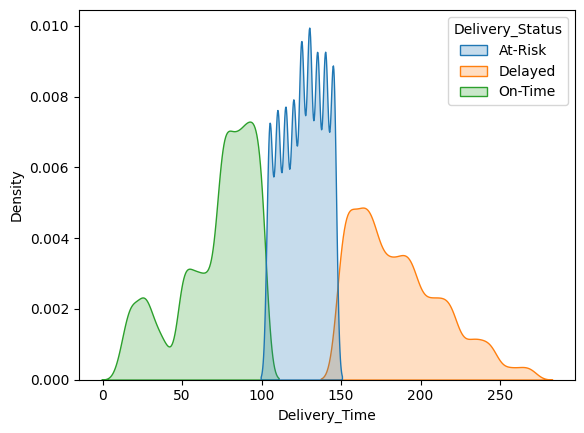

In [30]:
sns.kdeplot(
    data=df,
    x='Delivery_Time',
    hue='Delivery_Status',
    fill=True
)


* Distance vs delay

    * Does longer distance increase delay risk?



<Axes: xlabel='Delivery_Status', ylabel='delivery_distance_km'>

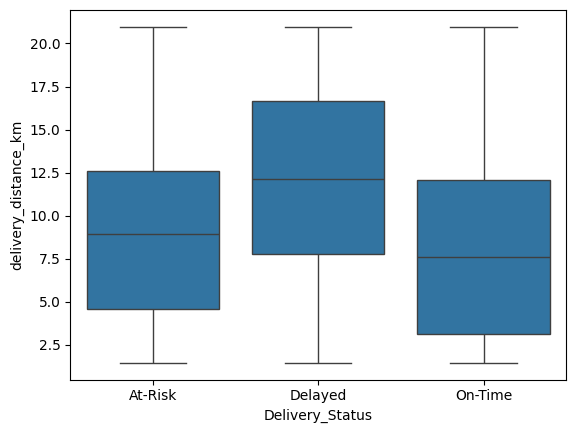

In [31]:
sns.boxplot(
    x='Delivery_Status',
    y='delivery_distance_km',
    data=df
)


* Distance distribution

    * Detects skew
    * Finds long-distance outliers



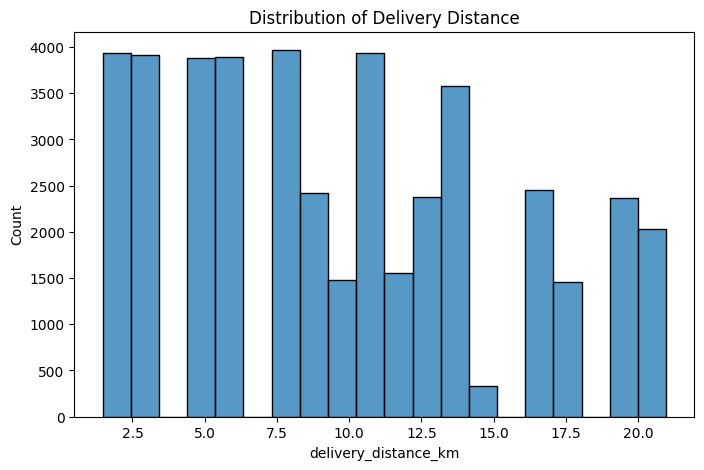

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_distance_km'],
             bins=20)

plt.title("Distribution of Delivery Distance")
plt.show()


* Hour of day vs delivery time

     * identifies peak-delay hours



<Axes: xlabel='order_hour', ylabel='Delivery_Time'>

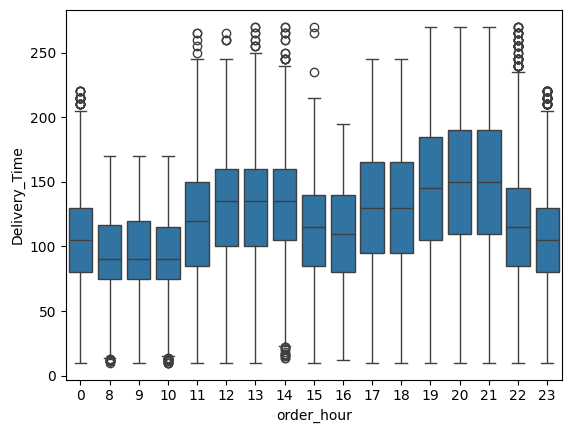

In [33]:
sns.boxplot(
    x='order_hour',
    y='Delivery_Time',
    data=df
)


* Weekday vs delay

<Axes: xlabel='order_day', ylabel='count'>

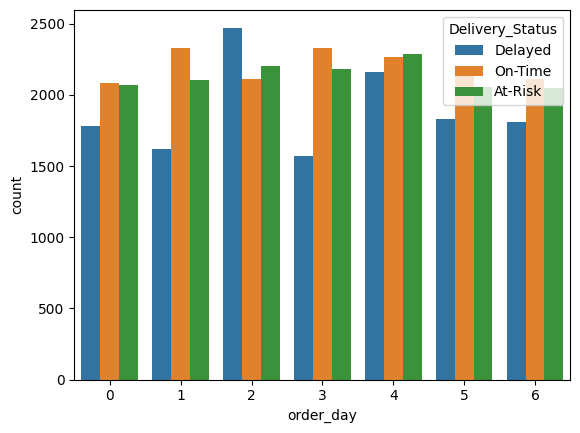

In [34]:
sns.countplot(
    x='order_day',
    hue='Delivery_Status',
    data=df
)


* Weekend vs delivery time

<Axes: xlabel='is_weekend', ylabel='Delivery_Time'>

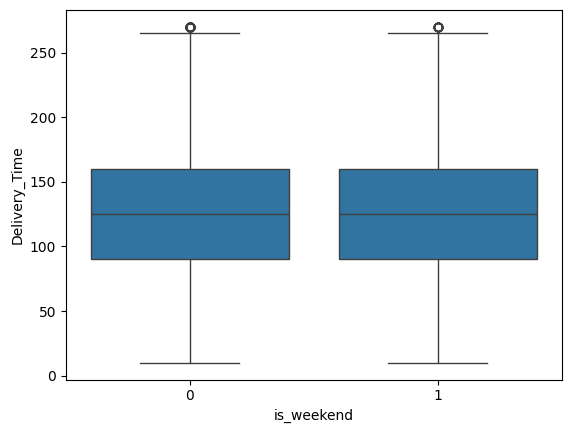

In [35]:
sns.boxplot(
    x='is_weekend',
    y='Delivery_Time',
    data=df
)


* Traffic vs delay

<Axes: xlabel='Traffic', ylabel='count'>

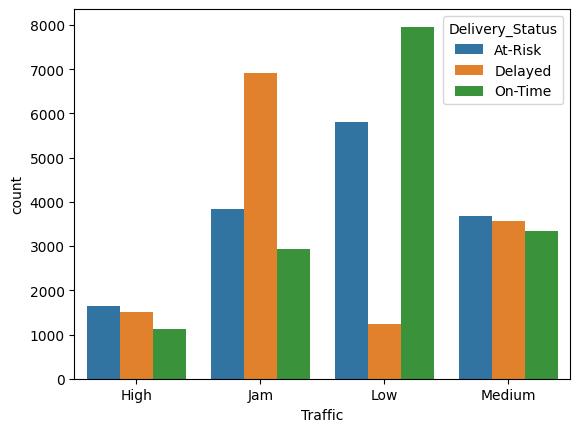

In [36]:
sns.countplot(
    x='Traffic',
    hue='Delivery_Status',
    data=df
)


* Weather vs delay

<Axes: xlabel='Weather', ylabel='count'>

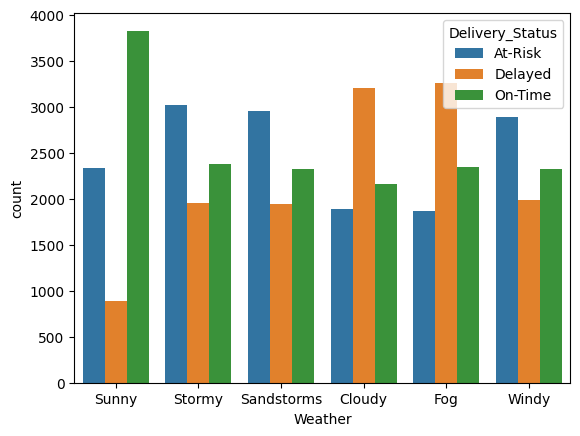

In [37]:
sns.countplot(
    x='Weather',
    hue='Delivery_Status',
    data=df
)


* traffic × distance

<Axes: xlabel='Delivery_Status', ylabel='traffic_distance'>

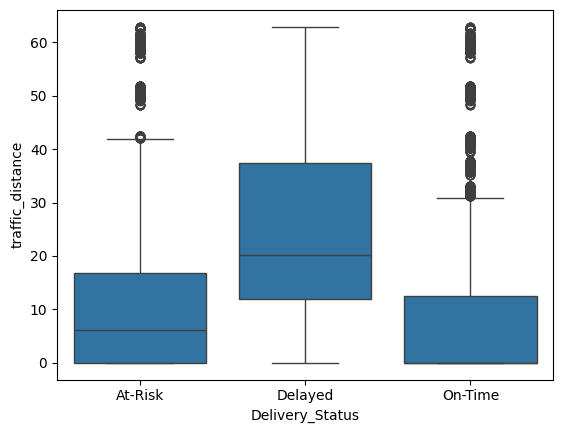

In [38]:
sns.boxplot(
    x='Delivery_Status',
    y='traffic_distance',
    data=df
)


In [39]:
df['Delivery_Time'].describe()


,Delivery_Time
count,43551.000000
mean,124.929783
std,51.939924
min,10.000000
25%,90.000000
50%,125.000000
75%,160.000000
max,270.000000


* Vehicle type vs delay

In [40]:
df['Vehicle'].value_counts()

,count
Vehicle,
motorcycle,25428
scooter,14582
van,3530
bicycle,11


<Axes: xlabel='Vehicle', ylabel='count'>

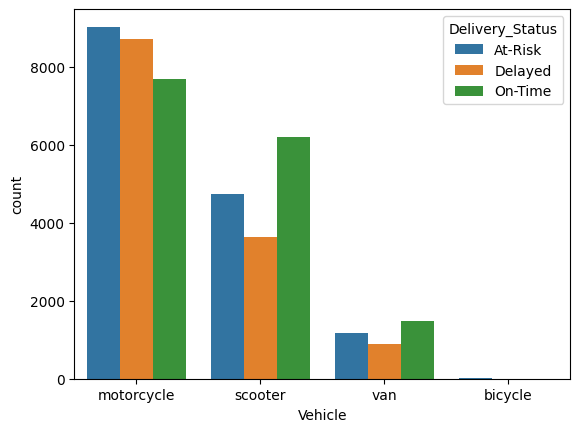

In [41]:
sns.countplot(
    x='Vehicle',
    hue='Delivery_Status',
    data=df
)


* Category vs delay

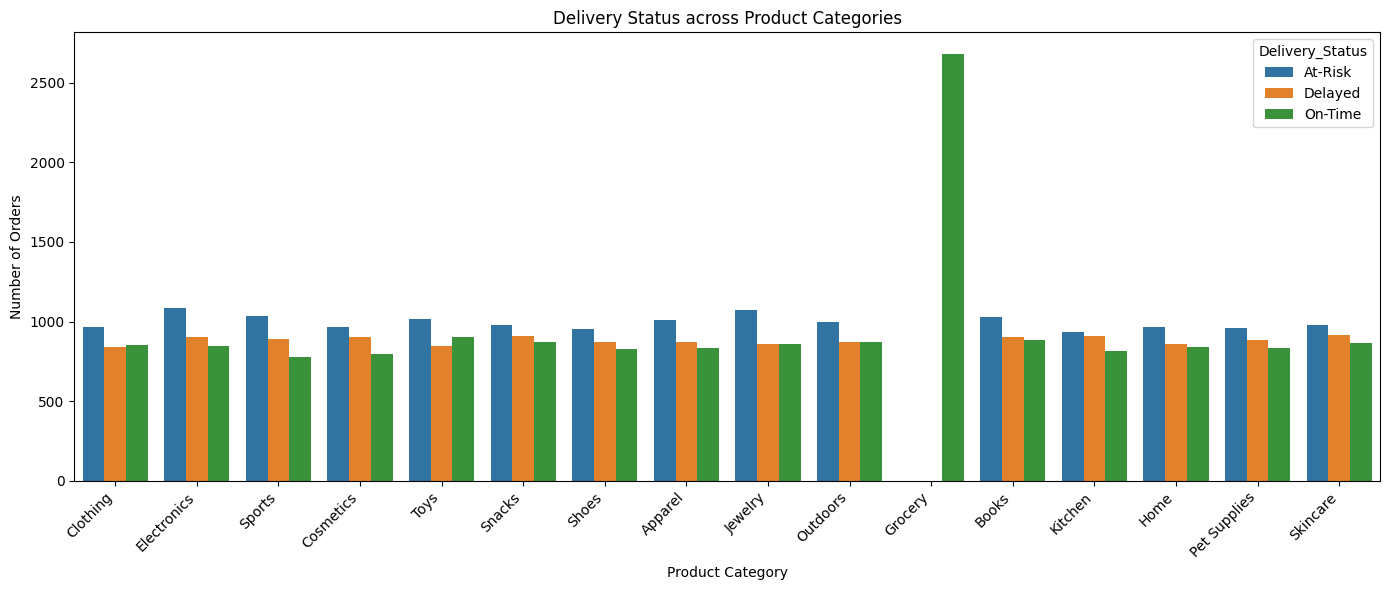

In [42]:
plt.figure(figsize=(14,6))
sns.countplot(
    x='Category',
    hue='Delivery_Status',
    data=df
)
plt.xticks(rotation=45, ha='right')
plt.title('Delivery Status across Product Categories')
plt.ylabel('Number of Orders')
plt.xlabel('Product Category')
plt.tight_layout()
plt.show()


* Area vs delay

<Axes: xlabel='Area', ylabel='count'>

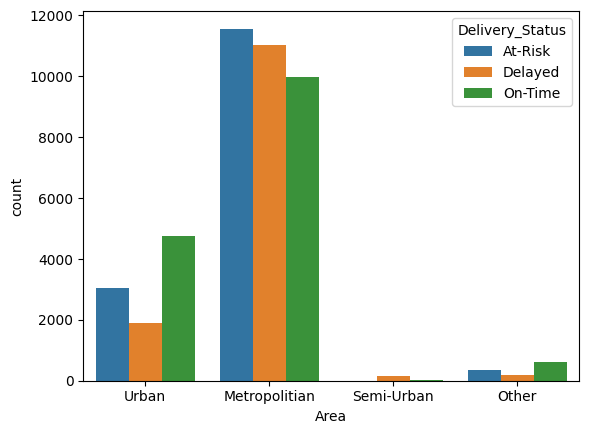

In [43]:
sns.countplot(
    x='Area',
    hue='Delivery_Status',
    data=df
)


* Agent rating vs delay

In [44]:
df['Agent_Rating'].describe()

,Agent_Rating
count,43551.000000
mean,4.633938
std,0.328756
min,1.000000
25%,4.500000
50%,4.700000
75%,4.900000
max,6.000000


<Axes: xlabel='Delivery_Status', ylabel='Agent_Rating'>

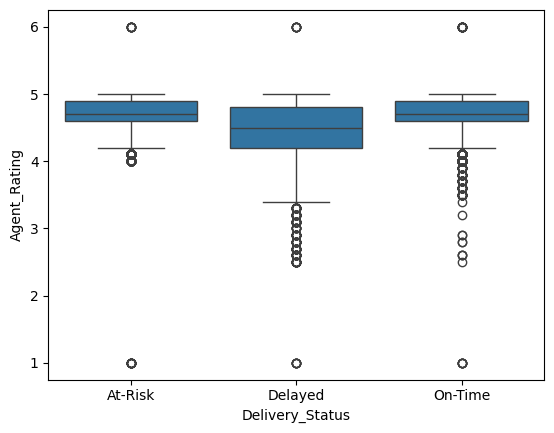

In [45]:
sns.boxplot(
    x='Delivery_Status',
    y='Agent_Rating',
    data=df
)


* Agent age vs delay

<Axes: xlabel='Delivery_Status', ylabel='Agent_Age'>

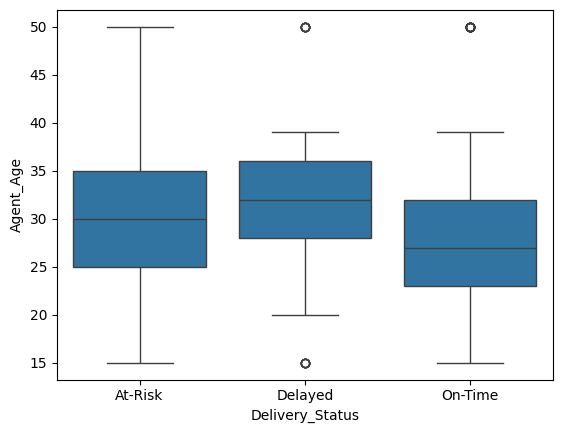

In [46]:
sns.boxplot(
    x='Delivery_Status',
    y='Agent_Age',
    data=df
)


* Rating bucket vs delay

<Axes: xlabel='rating_bucket', ylabel='count'>

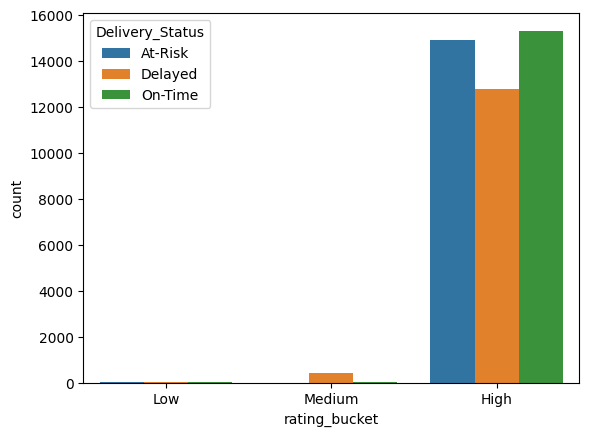

In [47]:
sns.countplot(
    x='rating_bucket',
    hue='Delivery_Status',
    data=df
)


##Correlation heatmap of all

<Axes: >

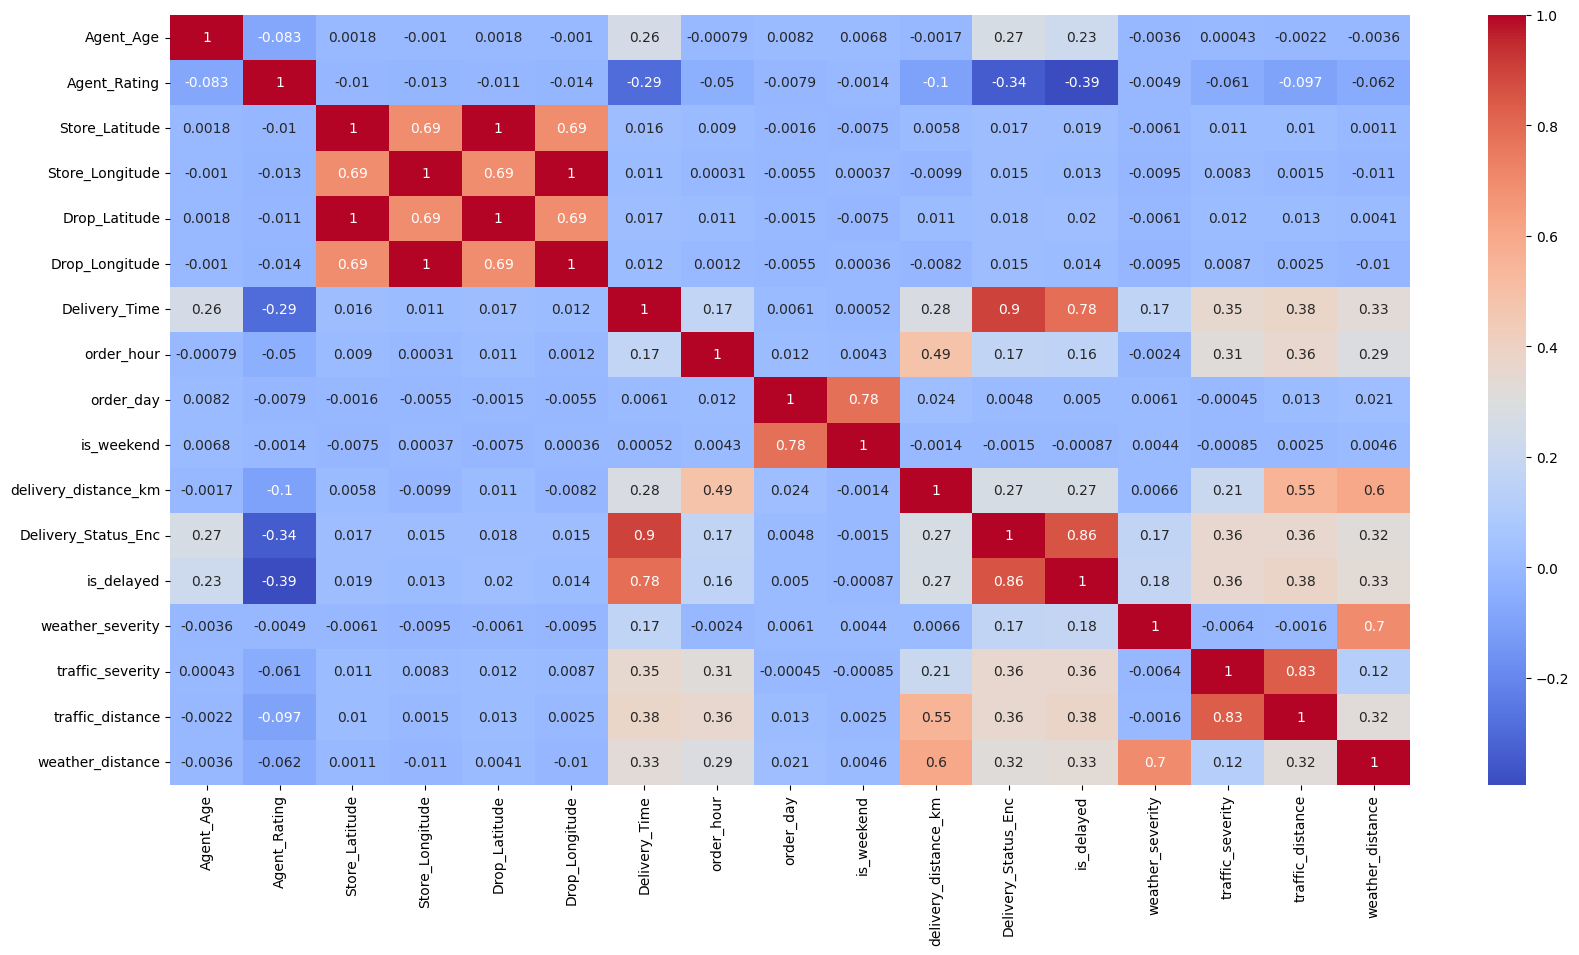

In [48]:
plt.figure(figsize=(20,10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)


## Exploratory Data Analysis – Key Insights

1. **Delivery distance is highly right-skewed**, with most orders occurring within short distances and a small number of extreme long-distance outliers.

2. **Longer delivery distances are strongly associated with delayed deliveries**, indicating distance as a critical operational risk factor.

3. **Traffic conditions significantly impact delivery performance**, with traffic jams showing the highest proportion of delayed orders.

4. **Weather conditions such as fog, storms, and sandstorms increase delay probability**, while sunny conditions show better on-time performance.

5. **Orders placed during peak hours (afternoon and evening)** tend to have higher delivery times compared to early morning hours.

6. **Metropolitan areas contribute the largest number of delayed deliveries**, likely due to higher order volume and congestion.

7. **Agent rating shows limited separation across delivery status**, suggesting that operational factors dominate over individual agent performance.

8. **Product category has a relatively weak influence on delivery delays**, indicating that logistics constraints matter more than item type.

9. **Weekend deliveries** also show no major changes, hence it is a weak feature.


10. **Interaction features such as traffic × distance amplify delay risk**, validating the importance of combining environmental and logistical factors.


## 9. Dropping Unneccessary Columns for Model

In [49]:
cols_to_drop = [
    'Order_ID',
    'Store_Latitude', 'Store_Longitude',
    'Drop_Latitude', 'Drop_Longitude',
    'Order_Date', 'Order_Time', 'Pickup_Time',
    'Delivery_Time',
    'is_delayed'
]

df_model = df.drop(columns=cols_to_drop, errors='ignore')


<Axes: >

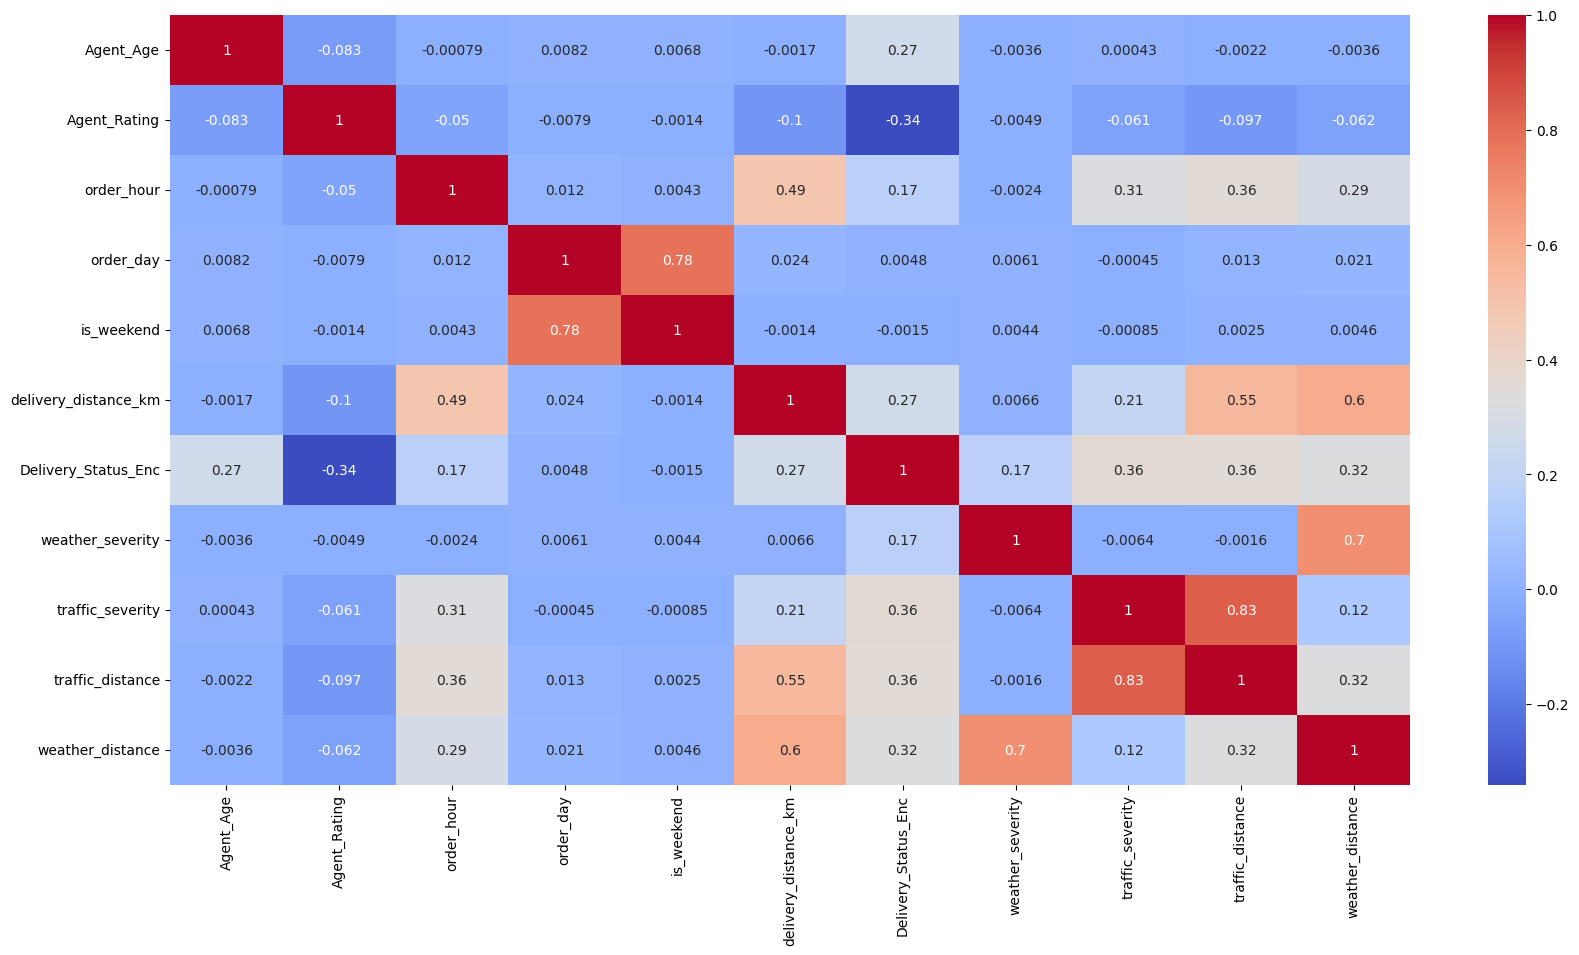

In [50]:
plt.figure(figsize=(20,10))
sns.heatmap(
    df_model.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)


In [51]:
df_model.columns

Index(['Agent_Age', 'Agent_Rating', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Category', 'order_hour', 'order_day', 'is_weekend',
       'delivery_distance_km', 'time_bucket', 'Delivery_Status',
       'Delivery_Status_Enc', 'weather_severity', 'traffic_severity',
       'agent_age_group', 'rating_bucket', 'traffic_distance',
       'weather_distance'],
      dtype='object')

In [52]:
df_model.to_csv('cleaned_amazon_delivery.csv', index=False)


In [53]:
from google.colab import files
files.download('cleaned_amazon_delivery.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

* checking class imbalance

Class distribution was analyzed and imbalance was observed in delayed deliveries.

In [54]:
df['Delivery_Status'].value_counts(normalize=True) * 100

,proportion
Delivery_Status,
On-Time,35.280476
At-Risk,34.322978
Delayed,30.396547


In [55]:
df.shape

(43551, 30)

##Model Application

## 1. Logistic Regression

* importing libraries

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer



* selecting data for model

In [57]:
X = df_model.drop(columns=['Delivery_Status', 'Delivery_Status_Enc'])
y = df_model['Delivery_Status_Enc']


In [58]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features

['Agent_Age',
 'Agent_Rating',
 'is_weekend',
 'delivery_distance_km',
 'weather_severity',
 'traffic_severity',
 'traffic_distance',
 'weather_distance']

In [59]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_features

['Weather', 'Traffic', 'Vehicle', 'Area', 'Category', 'time_bucket']

* test-train-split

In [60]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## class imbalance has been removed by stratify = y

* Preprocessing Step

In [61]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


* building pipeline

In [63]:
log_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',
        class_weight='balanced'
    ))
])


* Train the Model

In [64]:
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Agent_Age', 'Agent_Rating',
                                                   'is_weekend',
                                                   'delivery_distance_km',
                                                   'weather_severity',
                                                   'traffic_severity',
                                                   'traffic_distance',
                                                   'weather_distance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weather', 'Traffic',
                                                   'Vehicle', 'Area',
                                                   'Category',
                                                   'time_bucket'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    multi_class='multinomial'))])

* Predictions

In [65]:
y_pred_lr = log_reg.predict(X_test)

* Accuracy and Classification Report

In [66]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6764
              precision    recall  f1-score   support

           0       0.72      0.67      0.69      3073
           1       0.56      0.57      0.57      2990
           2       0.76      0.80      0.78      2648

    accuracy                           0.68      8711
   macro avg       0.68      0.68      0.68      8711
weighted avg       0.68      0.68      0.68      8711



<Axes: >

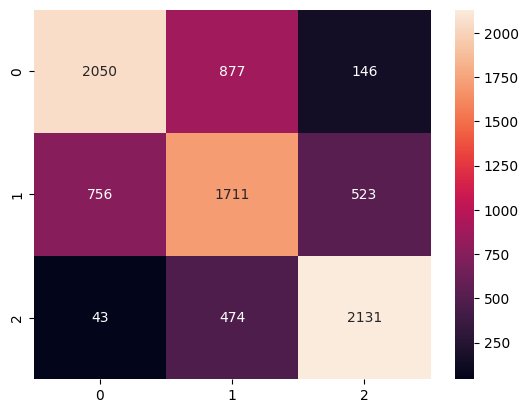

In [67]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')

## 2. Random Forest

* importing library

In [68]:
from sklearn.ensemble import RandomForestClassifier


* building pipeline

In [69]:
rf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])


* train the model

In [70]:
rf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Agent_Age', 'Agent_Rating',
                                                   'is_weekend',
                                                   'delivery_distance_km',
                                                   'weather_severity',
                                                   'traffic_severity',
                                                   'traffic_distance',
                                                   'weather_distance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weather', 'Traffic',
                                                   'Vehicle', 'Area',
                                                   'Category',
                                                   'time_bucket'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

* predictions

In [71]:
y_pred_rf = rf.predict(X_test)


* Accuracy and Classification Report

In [72]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7690
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      3073
           1       0.66      0.72      0.69      2990
           2       0.88      0.83      0.85      2648

    accuracy                           0.77      8711
   macro avg       0.78      0.77      0.77      8711
weighted avg       0.78      0.77      0.77      8711



In [119]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt']
}


grid = GridSearchCV(
    rf,
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Agent_Age',
                                                                          'Agent_Rating',
                                                                          'is_weekend',
                                                                          'delivery_distance_km',
                                                                          'weather_severity',
                                                                          'traffic_severity',
                                                                          'traffic_distance',
                                                                          'weather_distance']),
                                                                        ('cat',
                                                                         Pipeline(step...
                                                                         ['Weather',
                                                                          'Traffic',
                                                                          'Vehicle',
                                                                          'Area',
                                                                          'Category',
                                                                          'time_bucket'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=300,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 20],
                         'model__max_features': ['sqrt'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [200, 300]},
             scoring='f1_macro')

In [120]:
grid.best_params_


{'model__max_depth': 20,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 5,
 'model__n_estimators': 200}

In [121]:
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Agent_Age', 'Agent_Rating',
                                                   'is_weekend',
                                                   'delivery_distance_km',
                                                   'weather_severity',
                                                   'traffic_severity',
                                                   'traffic_distance',
                                                   'weather_distance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weather', 'Traffic',
                                                   'Vehicle', 'Area',
                                                   'Category',
                                                   'time_bucket'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [122]:
grid.best_score_


np.float64(0.780603187049658)

In [123]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.76      0.79      3073
           1       0.67      0.77      0.72      2990
           2       0.90      0.84      0.87      2648

    accuracy                           0.79      8711
   macro avg       0.80      0.79      0.79      8711
weighted avg       0.80      0.79      0.79      8711



In [124]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.76      0.79      3073
           1       0.67      0.77      0.72      2990
           2       0.90      0.84      0.87      2648

    accuracy                           0.79      8711
   macro avg       0.80      0.79      0.79      8711
weighted avg       0.80      0.79      0.79      8711



* confusion matrix

<Axes: >

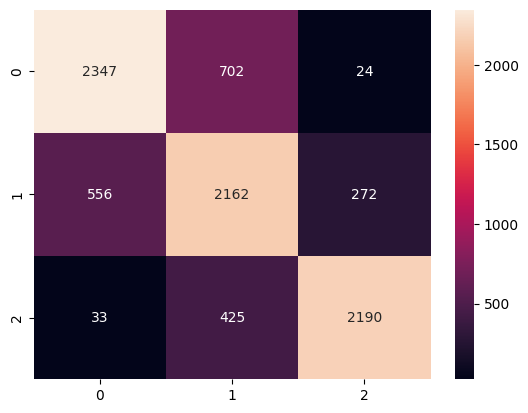

In [125]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')

## 3. HistGradient Boosting

* importing library

In [80]:
from sklearn.ensemble import HistGradientBoostingClassifier

* building pipeline

In [81]:
boosting_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.1,
        random_state=42
    ))
])


* train the model

In [82]:
boosting_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Agent_Age', 'Agent_Rating',
                                                   'is_weekend',
                                                   'delivery_distance_km',
                                                   'weather_severity',
                                                   'traffic_severity',
                                                   'traffic_distance',
                                                   'weather_distance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weather', 'Traffic',
                                                   'Vehicle', 'Area',
                                                   'Category',
                                                   'time_bucket'])])),
                ('model',
                 HistGradientBoostingClassifier(max_iter=300,
                                                random_state=42))])

* predictions

In [83]:
y_pred = boosting_pipeline.predict(X_test)


* Accuracy Score & Confusion Matrix

In [84]:
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.84      0.76      0.80      3073
           1       0.67      0.79      0.72      2990
           2       0.91      0.84      0.87      2648

    accuracy                           0.79      8711
   macro avg       0.81      0.79      0.80      8711
weighted avg       0.80      0.79      0.79      8711



* confusion matrix

<Axes: >

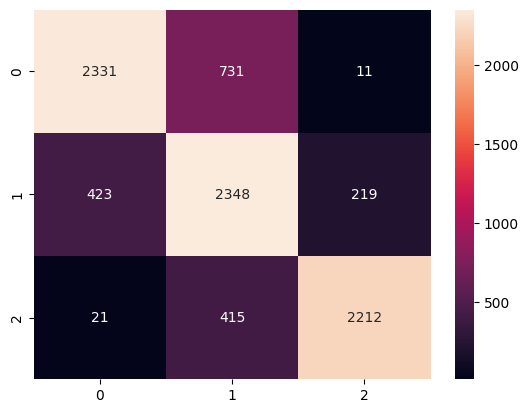

In [85]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

## Comparing Results

In [86]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'HistGradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr)*100,
        accuracy_score(y_test, y_pred_rf)*100,
        accuracy_score(y_test, y_pred)*100
    ]
})

results

,Model,Accuracy
0,Logistic Regression,67.638618
1,Random Forest,76.902767
2,HistGradient Boosting,79.106876


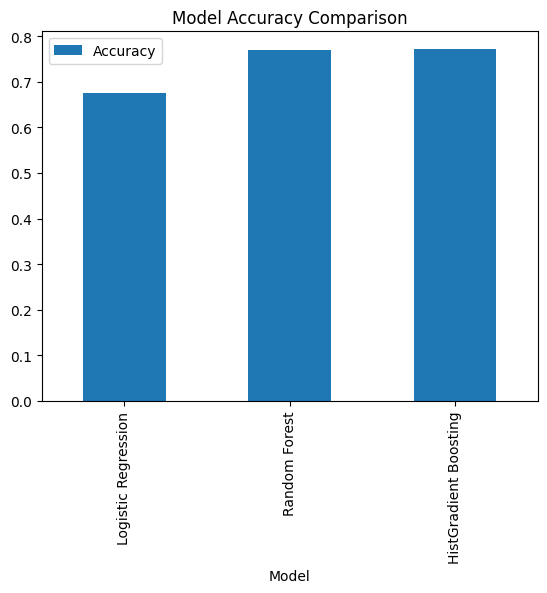

In [126]:
results.plot(x='Model', y='Accuracy', kind='bar')
plt.title("Model Accuracy Comparison")
plt.show()

In [127]:
from sklearn.metrics import recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'HistGradient Boosting'],

    'Recall_Delayed': [
        recall_score(y_test, y_pred_lr, average=None)[2],
        recall_score(y_test, y_pred_rf, average=None)[2],
        recall_score(y_test, y_pred, average=None)[2]
    ],

    'Macro_F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred, average='macro')
    ],

        'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred)
    ]
})

results


,Model,Recall_Delayed,Macro_F1,Accuracy
0,Logistic Regression,0.804758,0.680024,0.676386
1,Random Forest,0.827039,0.774314,0.769028
2,HistGradient Boosting,0.837236,0.791599,0.785903


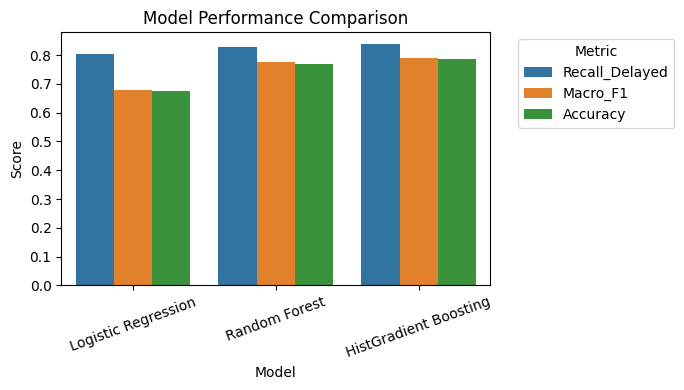

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.barplot(data=results.melt(id_vars='Model'),
            x='Model', y='value', hue='variable')

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


## acc to eda

In [90]:
X_weighted = X.copy()


In [91]:
# STRONG features (amplify)
strong_numeric = [
    'delivery_distance_km',
    'traffic_distance',
    'weather_distance',
    'order_hour'
]

strong_categorical = [
    'Traffic',
    'Weather'
]



# WEAK
weak_features = [
    'Category',
    'agent_age_group',
    'rating_bucket'
        'Vehicle',
    'Area',
    'Agent_Rating'
]


In [92]:
for col in strong_numeric:
    X_weighted[col + '_strong'] = X[col] * 2


In [93]:
for col in strong_categorical:
    X_weighted[col + '_strong'] = X[col]


In [94]:
print("Original shape:", X.shape)
print("Weighted shape:", X_weighted.shape)


Original shape: (43551, 18)
Weighted shape: (43551, 24)


In [95]:
from sklearn.model_selection import train_test_split

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_weighted,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [96]:
numeric_features_weighted = list(numeric_features) + [
    col + '_strong' for col in strong_numeric
]


In [97]:
categorical_features_weighted = list(categorical_features) + [
    col + '_strong' for col in strong_categorical
]


In [98]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_weighted = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_weighted),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_weighted)
    ]
)


In [99]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_weighted = Pipeline(steps=[
    ('preprocess', preprocessor_weighted),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])


In [100]:
rf_weighted.fit(Xw_train, yw_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Agent_Age', 'Agent_Rating',
                                                   'is_weekend',
                                                   'delivery_distance_km',
                                                   'weather_severity',
                                                   'traffic_severity',
                                                   'traffic_distance',
                                                   'weather_distance',
                                                   'delivery_distance_km_strong',
                                                   'traffic_distance_strong',
                                                   'weather_distance_strong',
                                                   'order_hour_strong']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Weather', 'Traffic',
                                                   'Vehicle', 'Area',
                                                   'Category', 'time_bucket',
                                                   'Traffic_strong',
                                                   'Weather_strong'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [101]:
from sklearn.metrics import classification_report

yw_pred = rf_weighted.predict(Xw_test)
print(classification_report(yw_test, yw_pred))


              precision    recall  f1-score   support

           0       0.80      0.77      0.78      3073
           1       0.66      0.72      0.69      2990
           2       0.88      0.82      0.85      2648

    accuracy                           0.77      8711
   macro avg       0.78      0.77      0.77      8711
weighted avg       0.78      0.77      0.77      8711



In [102]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
Delivery_Status_Enc
0    0.352813
1    0.343226
2    0.303961
Name: proportion, dtype: float64

Test distribution:
Delivery_Status_Enc
0    0.352772
1    0.343244
2    0.303983
Name: proportion, dtype: float64
